<a href="https://colab.research.google.com/github/dimpi2207/Breast-cancer/blob/main/BC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv("https://media.githubusercontent.com/media/dimpi2207/earthquake/refs/heads/main/Downloads/archive%20(2)/earthquakes_1900_2026.csv")
df.head()



,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,cent19000105190000000,1900-01-05 19:00:00+00:00,1900,1,5,19,-3.00,102.00,NaN,7.0,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T00:16:56.005Z,reviewed
1,cent19000111090700000,1900-01-11 09:07:00+00:00,1900,1,11,9,-5.00,148.00,NaN,7.0,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T22:55:15.621Z,reviewed
2,cent19000120063300000,1900-01-20 06:33:00+00:00,1900,1,20,6,20.00,-105.00,NaN,7.3,...,0,Great (7-8),NaN,NaN,NaN,NaN,NaN,cent,2025-04-19T23:36:34.400Z,reviewed
3,cent19000131192200000,1900-01-31 19:22:00+00:00,1900,1,31,19,48.00,146.00,450.0,7.5,...,0,Great (7-8),Deep (300-700km),NaN,NaN,NaN,NaN,cent,2025-04-26T21:47:57.256Z,reviewed
4,ushis388,1900-04-09 14:00:00+00:00,1900,4,99,14,41.37,-81.85,0.0,3.4,...,0,Light (3-4),Shallow (0-70km),NaN,NaN,NaN,NaN,ushis,2023-12-03T23:47:09.672Z,automatic


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054683 entries, 0 to 1054682
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1054683 non-null  object 
 1   time            1054683 non-null  object 
 2   year            1054683 non-null  int64  
 3   month           1054683 non-null  int64  
 4   day_of_year     1054683 non-null  int64  
 5   hour            1054683 non-null  int64  
 6   latitude        1054683 non-null  float64
 7   longitude       1054683 non-null  float64
 8   depth           1053791 non-null  float64
 9   mag             1054683 non-null  float64
 10  magType         1054599 non-null  object 
 11  place           1054683 non-null  object 
 12  type            1054683 non-null  object 
 13  tsunami         1054683 non-null  int64  
 14  mag_category    1054683 non-null  object 
 15  depth_category  1053785 non-null  object 
 16  nst             558968 non-null   fl

In [35]:
df.columns = df.columns.str.strip()

In [36]:
def categorize_mag(mag):
    if mag < 4:
        return "Low"
    elif mag < 6:
        return "Medium"
    else:
        return "High"

df['mag_category'] = df['mag'].apply(categorize_mag)

In [37]:
df['mag_category'].value_counts()

,count
mag_category,
Medium,524944
Low,515319
High,14420


In [38]:
df.describe()


,year,month,day_of_year,hour,latitude,longitude,depth,mag,tsunami,nst,gap,dmin,rms
count,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.054683e+06,1.053791e+06,1.054683e+06,1054683.0,558968.000000,673635.000000,380975.000000,878131.000000
mean,2.003353e+03,6.471018e+00,1.814476e+02,1.155436e+01,2.016444e+01,-2.114013e+01,5.329371e+01,3.844124e+00,0.0,33.927071,139.192121,2.136737,0.695564
std,1.683438e+01,3.418864e+00,1.044286e+02,6.969818e+00,2.940922e+01,1.205227e+02,9.954571e+01,9.303126e-01,0.0,51.022166,79.236030,3.921382,0.470158
min,1.900000e+03,1.000000e+00,1.000000e+00,0.000000e+00,-8.449320e+01,-1.799997e+02,-4.000000e+00,7.000000e-01,0.0,0.000000,0.000000,0.000000,-1.000000
25%,1.994000e+03,4.000000e+00,9.200000e+01,5.000000e+00,-3.247350e+00,-1.215118e+02,1.000000e+01,2.940000e+00,0.0,10.000000,75.000000,0.207000,0.360000
50%,2.006000e+03,7.000000e+00,1.820000e+02,1.200000e+01,2.943500e+01,-6.684680e+01,1.978000e+01,4.000000e+00,0.0,19.000000,123.000000,0.877900,0.710000
75%,2.017000e+03,9.000000e+00,2.710000e+02,1.800000e+01,4.057282e+01,1.190265e+02,4.580000e+01,4.500000e+00,0.0,38.000000,194.000000,2.446000,1.000000
max,2.026000e+03,1.200000e+01,3.660000e+02,2.300000e+01,8.738600e+01,1.800000e+02,7.358000e+02,9.500000e+00,0.0,934.000000,360.000000,127.420000,104.330000


In [39]:
df.isnull().sum()

,0
id,0
time,0
year,0
month,0
day_of_year,0
hour,0
latitude,0
longitude,0
depth,892
mag,0


In [109]:
import joblib
l1 = LabelEncoder()
for col in df.columns:
  if df[col].dtype=="object":
    df[col]=l1.fit_transform(df[col])
joblib.dump(l1,"encoders.pkl")


['encoders.pkl']

In [41]:
df.head()

,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,68522,0,1900,1,5,19,-3.00,102.00,NaN,7.0,...,0,0,3,NaN,NaN,NaN,NaN,4,782610,2
1,68523,1,1900,1,11,9,-5.00,148.00,NaN,7.0,...,0,0,3,NaN,NaN,NaN,NaN,4,782629,2
2,68524,2,1900,1,20,6,20.00,-105.00,NaN,7.3,...,0,0,3,NaN,NaN,NaN,NaN,4,782641,2
3,68525,3,1900,1,31,19,48.00,146.00,450.0,7.5,...,0,0,0,NaN,NaN,NaN,NaN,4,782779,2
4,544503,4,1900,4,99,14,41.37,-81.85,0.0,3.4,...,0,1,2,NaN,NaN,NaN,NaN,28,768138,0


In [42]:
df.corr()

,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
id,1.000000,-0.102324,0.032480,-0.001442,-0.000523,-0.001692,-0.271862,0.384862,0.107138,0.317273,...,NaN,0.312491,-0.080585,0.124778,0.027642,0.181193,0.452372,0.753207,-0.454551,0.067625
time,-0.102324,1.000000,0.928124,0.000200,-0.000850,-0.005365,-0.033639,-0.026704,0.048221,-0.067716,...,NaN,0.091168,-0.061947,0.144495,-0.117989,0.189890,-0.060869,0.139249,0.565449,-0.050863
year,0.032480,0.928124,1.000000,-0.015239,-0.016114,-0.002966,-0.041102,-0.003131,0.059804,-0.120380,...,NaN,0.113477,-0.080534,0.154975,-0.157197,0.172276,-0.007132,0.213226,0.405001,-0.043754
month,-0.001442,0.000200,-0.015239,1.000000,0.996451,0.002442,0.000062,-0.001328,0.004621,0.003029,...,NaN,0.002583,-0.003168,-0.005357,-0.012477,0.017460,0.000230,-0.011082,0.006497,0.002575
day_of_year,-0.000523,-0.000850,-0.016114,0.996451,1.000000,0.002720,0.000117,-0.000888,0.004898,0.003223,...,NaN,0.002836,-0.003451,-0.005404,-0.011800,0.017929,0.000314,-0.010099,0.005699,0.002695
hour,-0.001692,-0.005365,-0.002966,0.002442,0.002720,1.000000,0.005351,0.005526,-0.000333,0.000343,...,NaN,0.001390,0.000610,-0.002443,-0.025832,0.004977,0.015233,0.001771,0.001655,-0.003425
latitude,-0.271862,-0.033639,-0.041102,0.000062,0.000117,0.005351,1.000000,-0.210197,-0.278294,-0.467036,...,NaN,-0.423492,0.252550,-0.025517,0.127602,-0.424076,-0.218192,-0.367226,0.145273,-0.018702
longitude,0.384862,-0.026704,-0.003131,-0.001328,-0.000888,0.005526,-0.210197,1.000000,0.046004,0.496962,...,NaN,0.455025,-0.055674,0.152684,-0.179710,0.217877,0.348761,0.447634,-0.250782,0.055312
depth,0.107138,0.048221,0.059804,0.004621,0.004898,-0.000333,-0.278294,0.046004,1.000000,0.216581,...,NaN,0.244690,-0.888790,0.104610,-0.080738,0.128383,0.114308,0.163362,-0.074386,0.023588
mag,0.317273,-0.067716,-0.120380,0.003029,0.003223,0.000343,-0.467036,0.496962,0.216581,1.000000,...,NaN,0.677390,-0.170671,0.480589,-0.329384,0.415054,0.482227,0.428005,-0.055595,0.058847


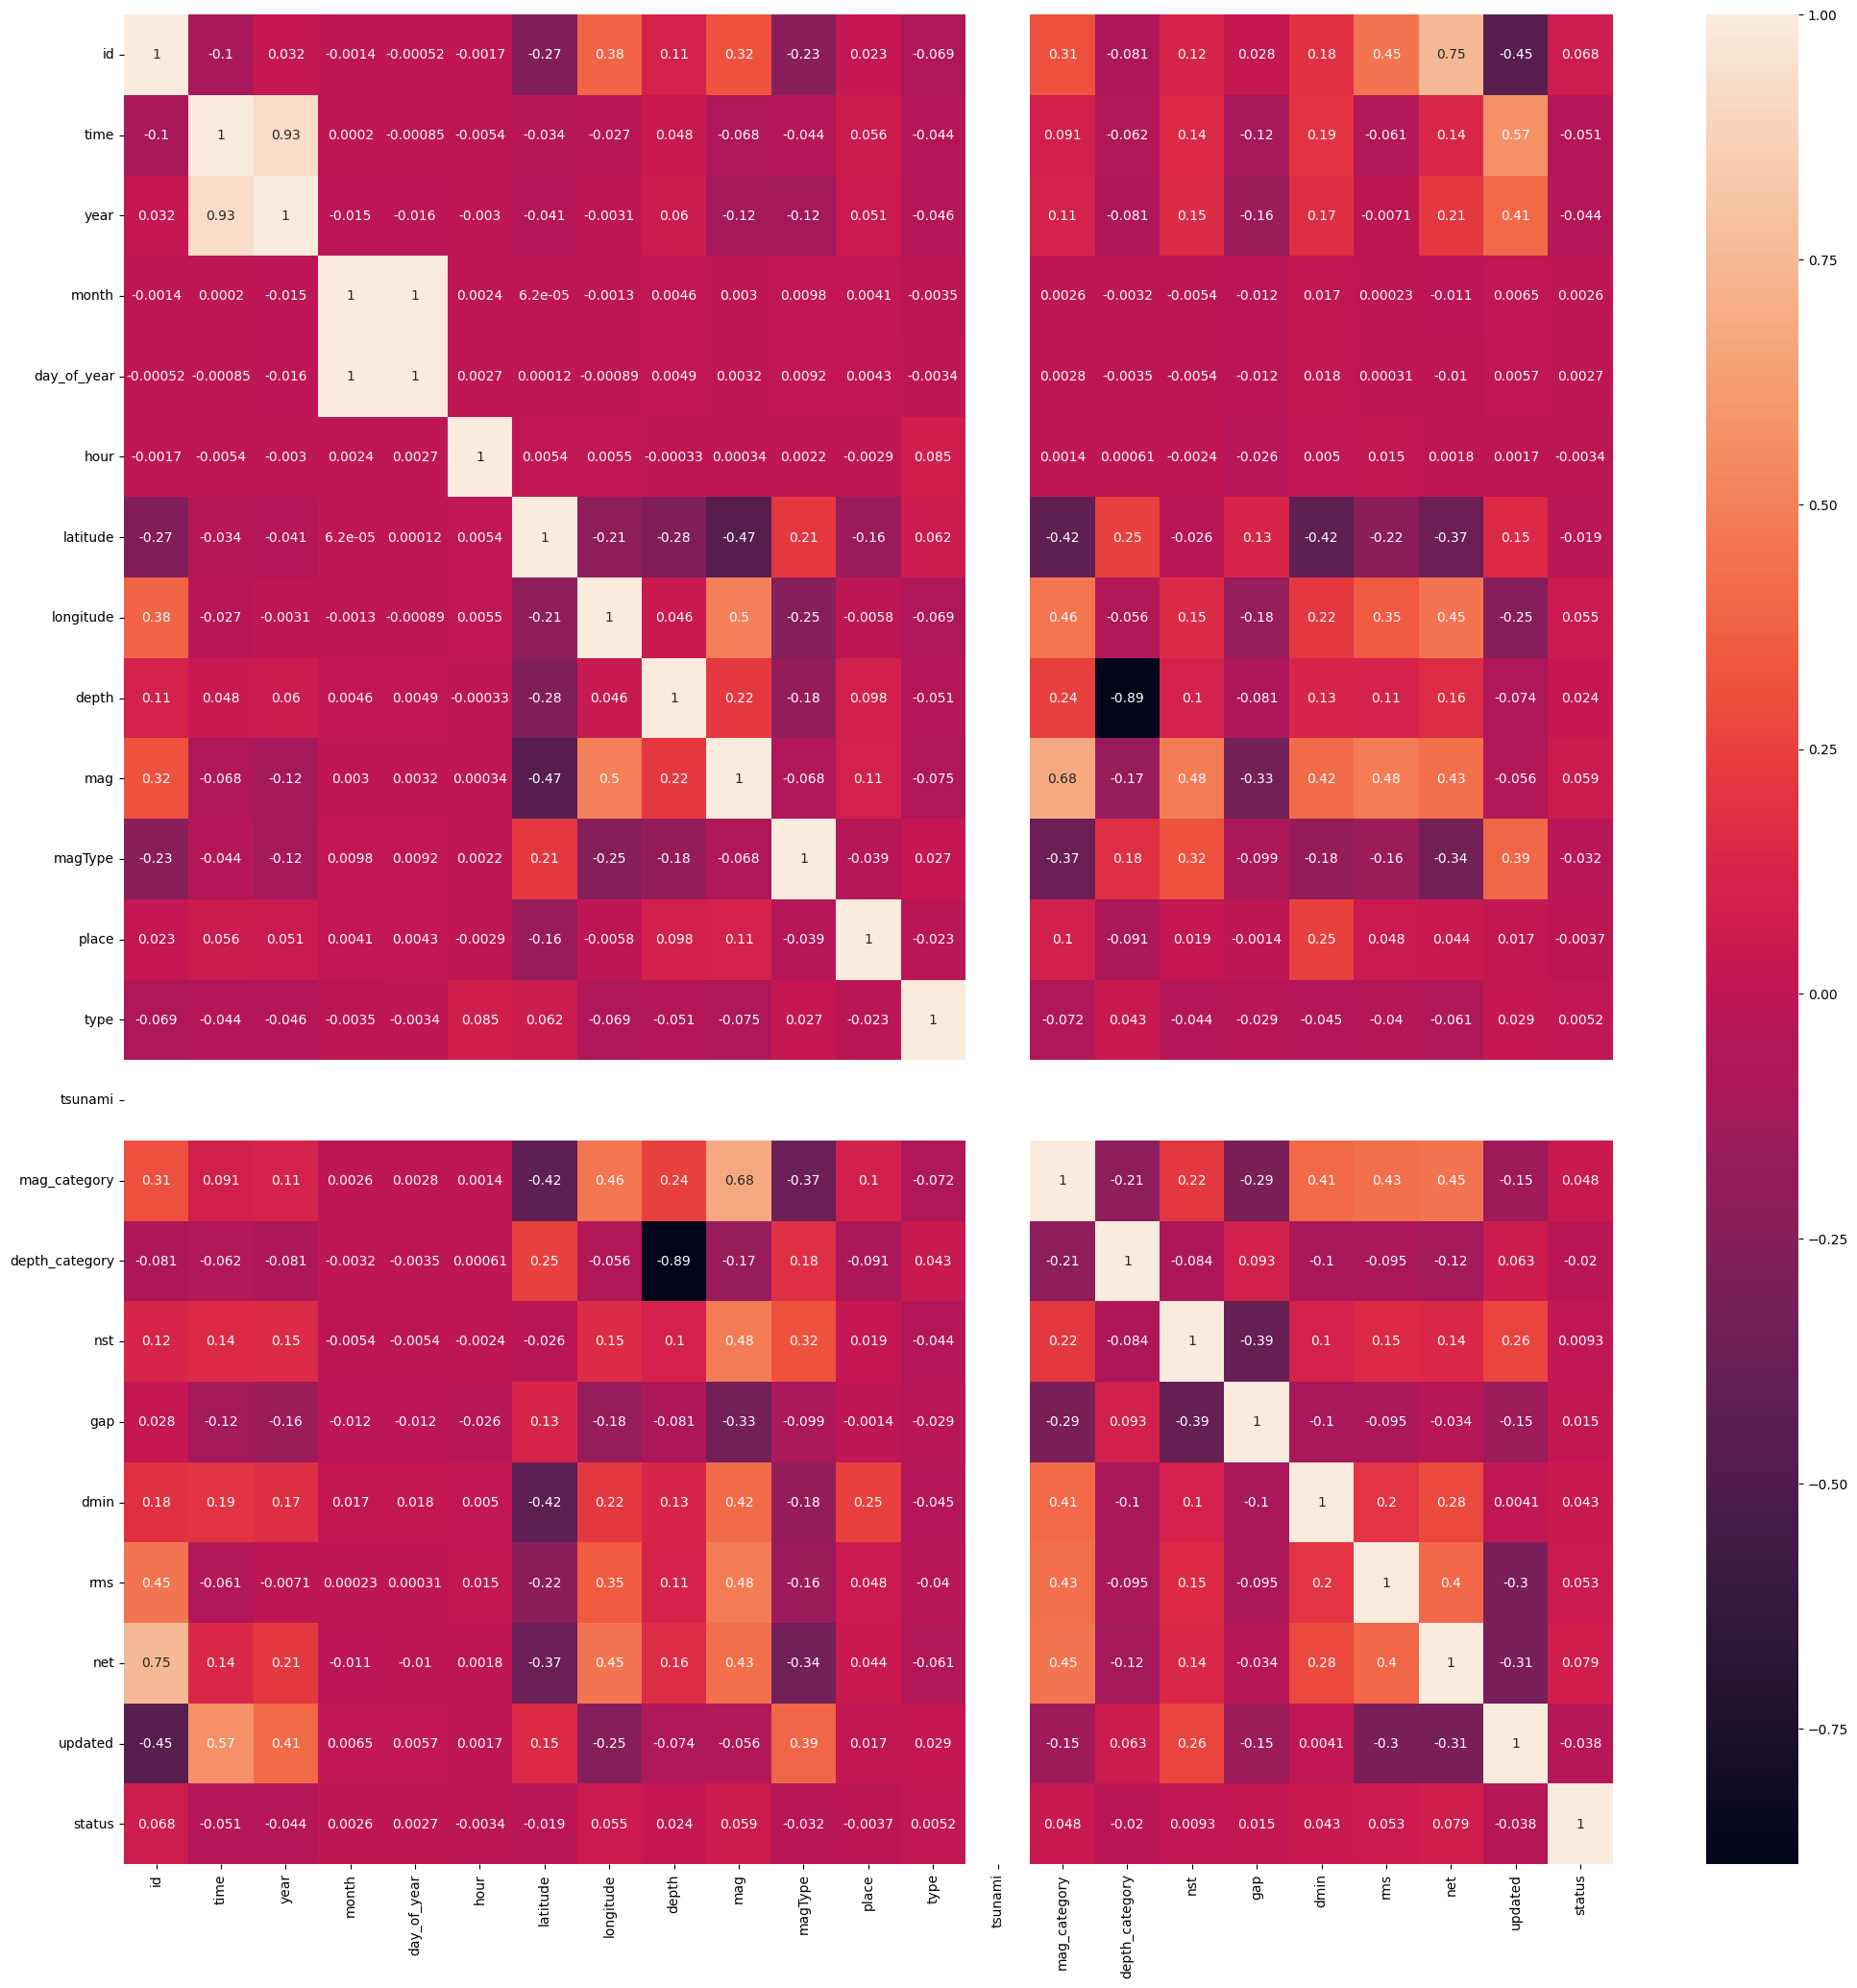

In [43]:
import seaborn as sns
corr = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corr, annot=True)
plt.show()


In [44]:
drop_cols = [
    'id',
    'time',
    'day_of_year',
    'mag_category',
    'depth_category',
    'place',
    'updated',
    'nst',
    'gap',
    'dmin',
    'rms'
]

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

In [45]:
df.head()

,year,month,hour,latitude,longitude,depth,mag,magType,type,tsunami,net,status
0,1900,1,19,-3.00,102.00,NaN,7.0,24,7,0,4,2
1,1900,1,9,-5.00,148.00,NaN,7.0,24,7,0,4,2
2,1900,1,6,20.00,-105.00,NaN,7.3,28,7,0,4,2
3,1900,1,19,48.00,146.00,450.0,7.5,18,7,0,4,2
4,1900,4,14,41.37,-81.85,0.0,3.4,15,17,0,28,0


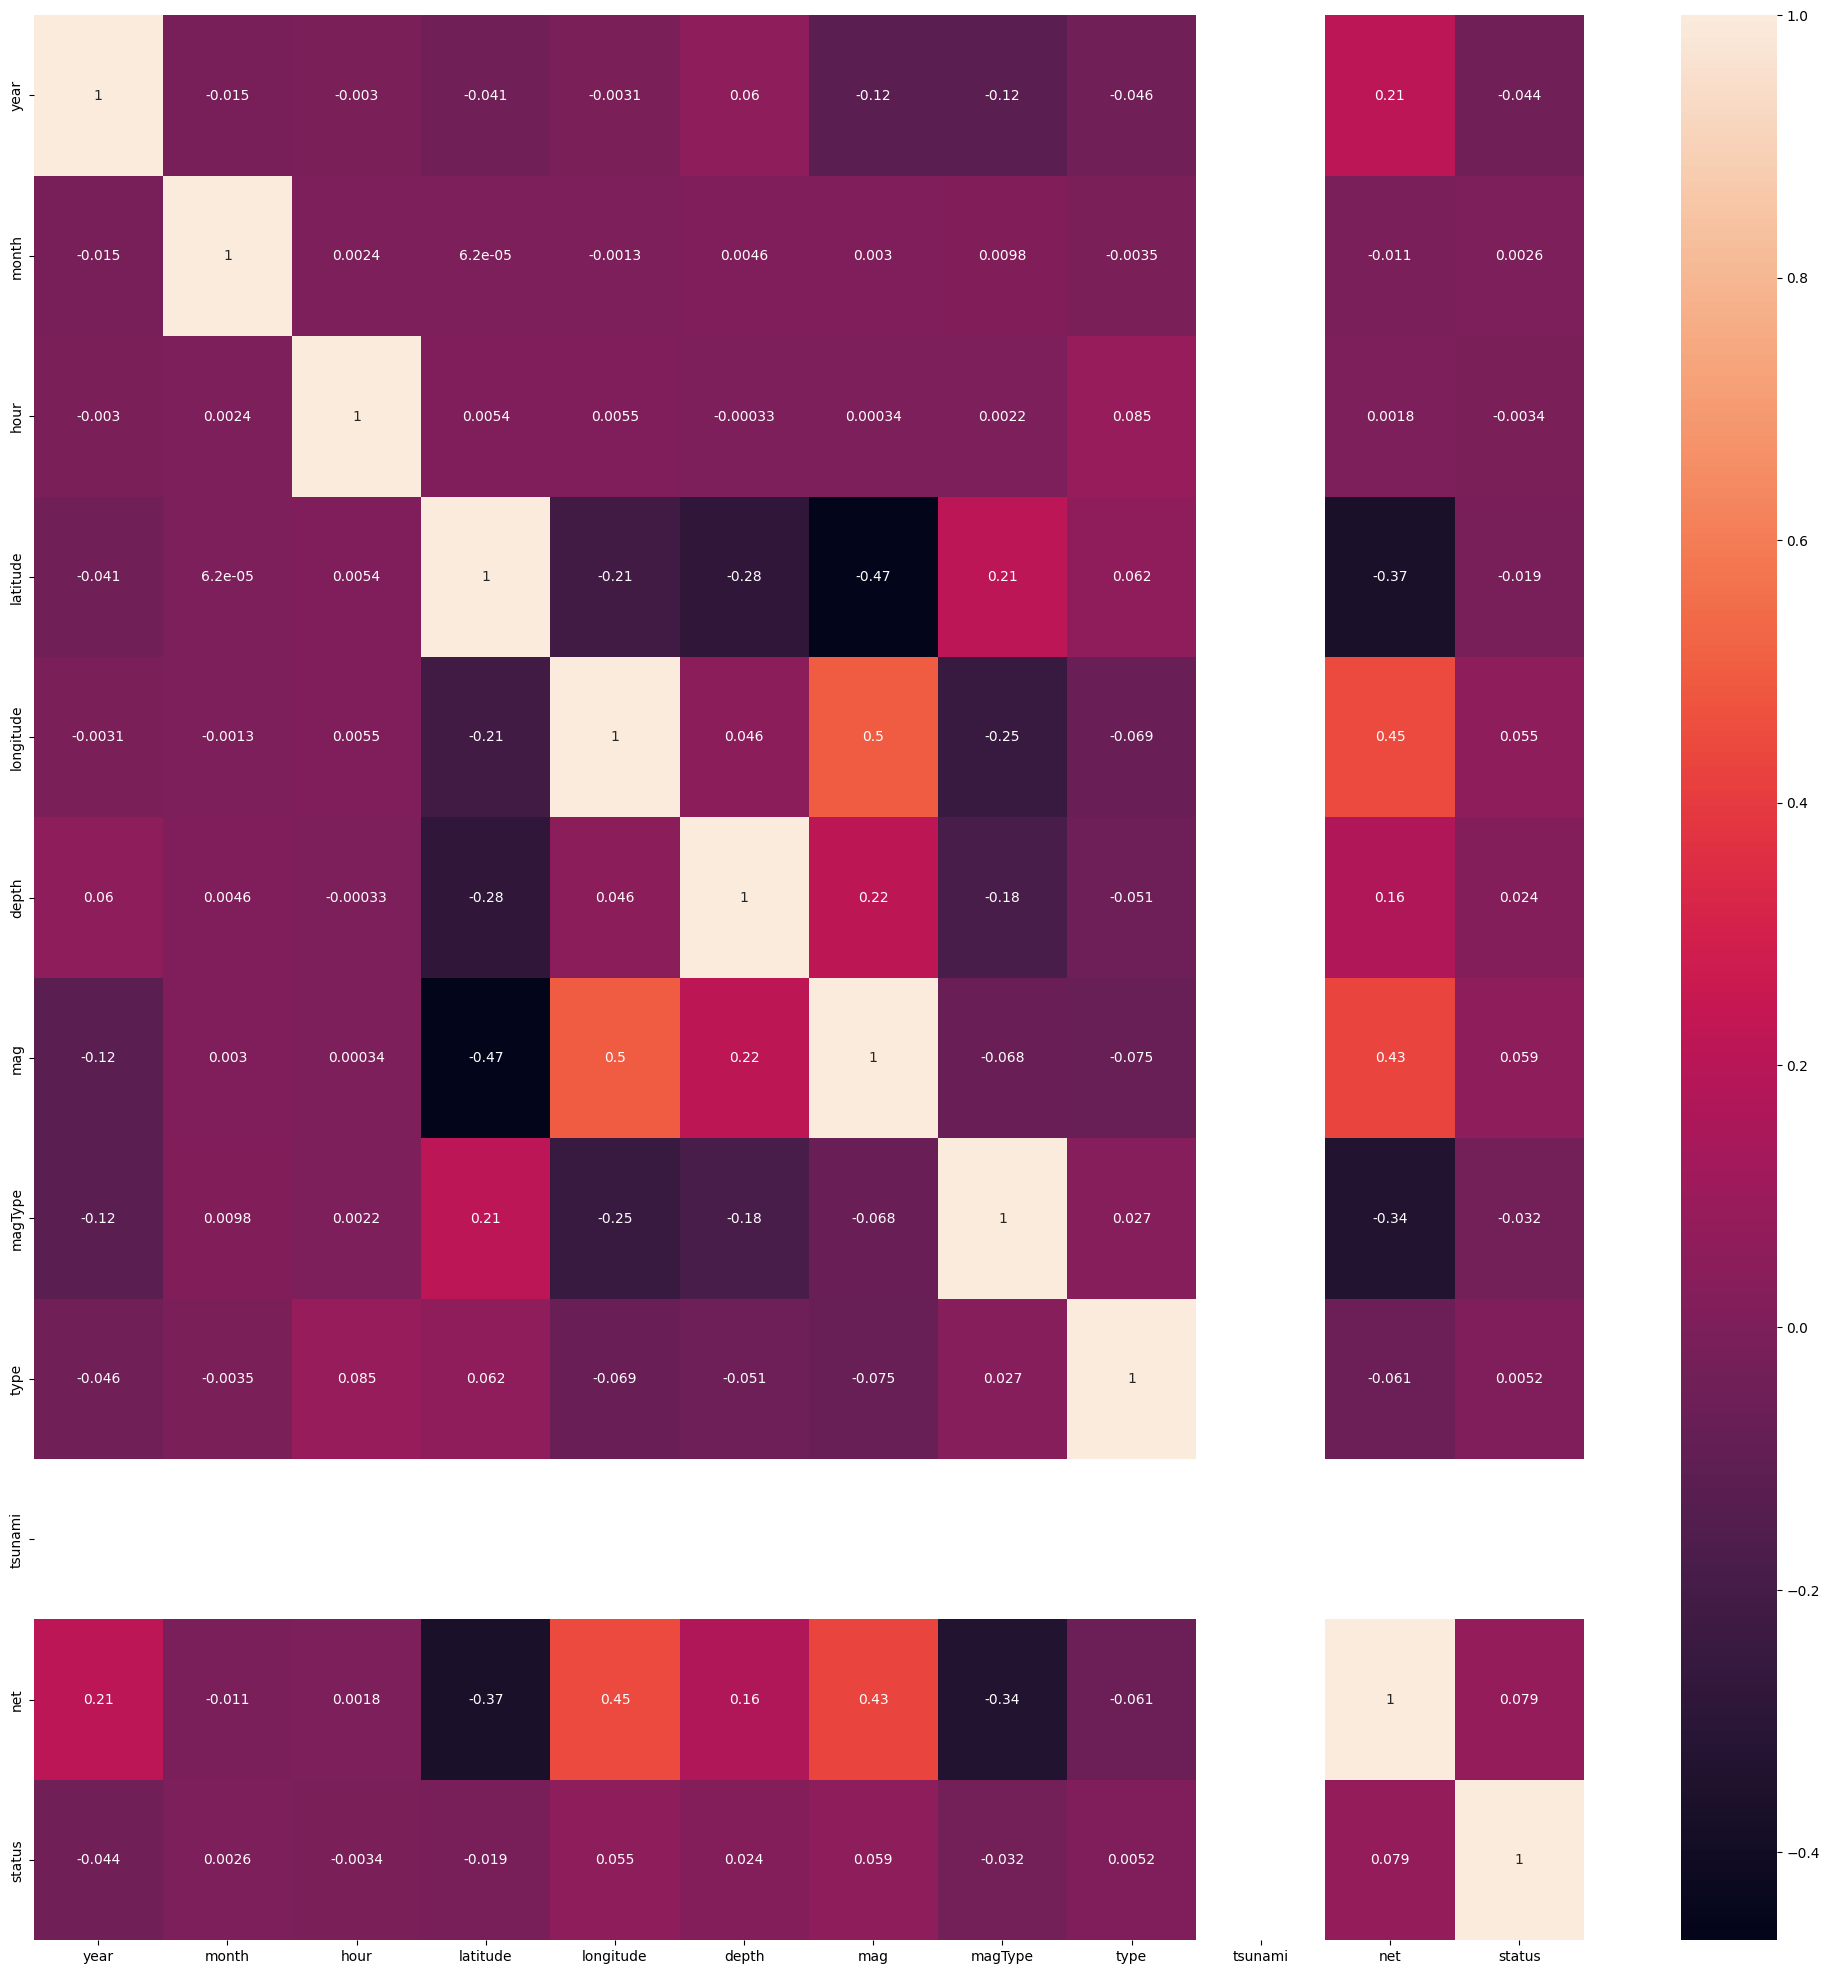

In [46]:
import seaborn as sns
corr = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corr, annot=True)
plt.show()

In [47]:
df.isnull().sum()

,0
year,0
month,0
hour,0
latitude,0
longitude,0
depth,892
mag,0
magType,0
type,0
tsunami,0


In [48]:
# Remove columns with only 1 unique value
for col in df.columns:
    if df[col].nunique() <= 1:
        print("Dropping:", col)
        df.drop(columns=[col], inplace=True)

Dropping: tsunami


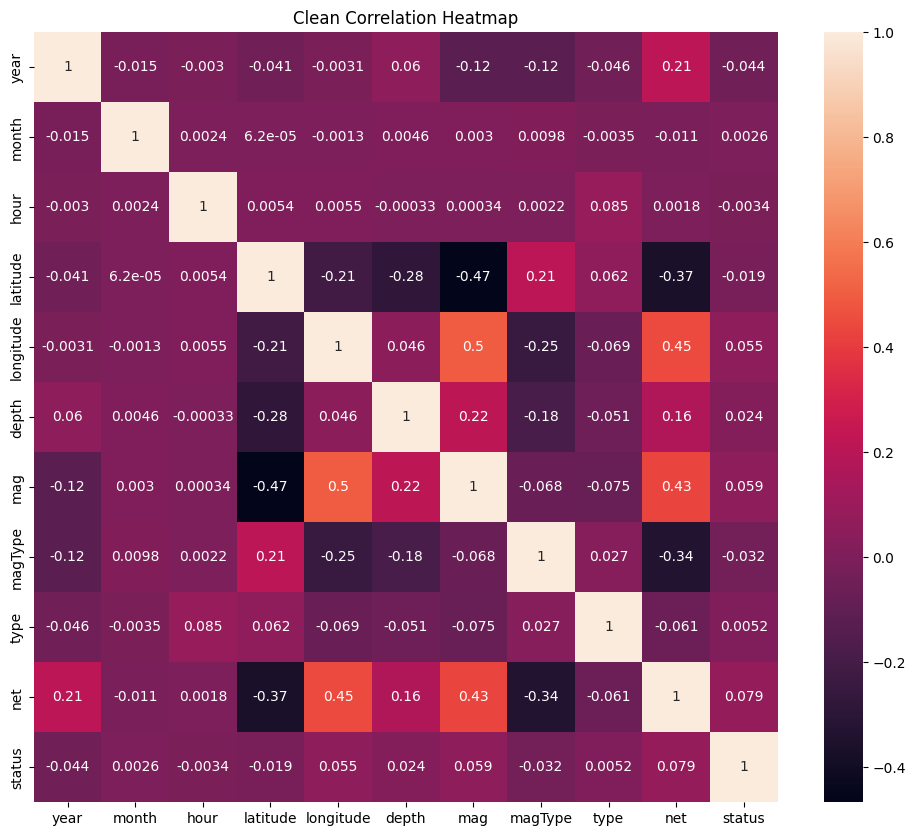

In [49]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True )
plt.title("Clean Correlation Heatmap")
plt.show()

In [112]:
from sklearn.impute import SimpleImputer
target = 'target'  # change if your column name is different

df['target'] = (df['mag'] > 5).astype(int)

# Impute missing values in 'depth' column before creating X
imputer = SimpleImputer(strategy='mean')
df['depth'] = imputer.fit_transform(df[['depth']])

X = df.select_dtypes(include=['number']).drop(['target', 'mag'], axis=1)
y = df['target']

In [114]:
# Split for test & training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


MODELS

In [52]:
import joblib
from sklearn.ensemble import RandomForestClassifier

#Random Forest model 3
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf, 'rf_model.pkl')


['rf_model.pkl']

In [53]:
#for prediction
y_pred = rf.predict(X_test)

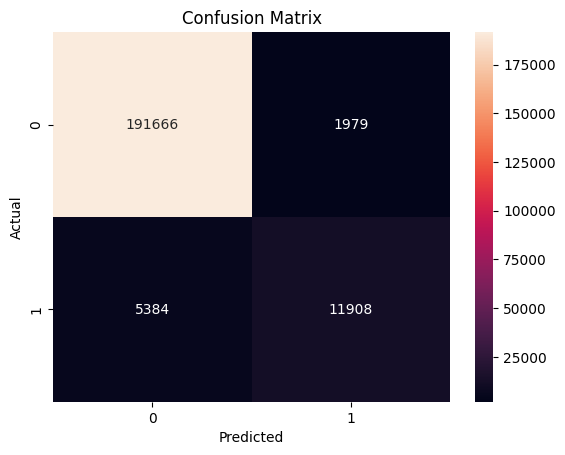

In [54]:
#confusion matrix for random forest
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.965093843185406


In [56]:
print(X_train['magType'].unique())
print(X_train['net'].unique())
print(X_train['type'].unique())
print(X_train['status'].unique())

[10 19 14 33 11  1 30 28 32 24 16  7 12 13 22 29  5  9 15 21  6 20 17  2
 35  8 34 23  3  0 27 31 18 25  4]
[27  5 30  1 22 16 10 24 11 29 17 26 18 23 13 12 28  0 20 15  9 14 19  2
  6 25  3  4 21 31  8  7]
[ 7  9 14 15 17 18 10 16 20 13 19  5 11  4  1  6  3  8 12  2]
[2 0 1]


In [57]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

   Actual  Predicted
0       0          1
1       0          0
2       0          0
3       0          0
4       1          1
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [79]:
#for xgboost
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
joblib.dump(xgb, 'xgb_model.pkl')

['xgb_model.pkl']

In [80]:
#xgboost prediction
y_pred_xgb = xgb.predict(X_test)

In [81]:
from sklearn.metrics import classification_report
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9659092525256356
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    193645
           1       0.87      0.69      0.77     17292

    accuracy                           0.97    210937
   macro avg       0.92      0.84      0.87    210937
weighted avg       0.96      0.97      0.96    210937



In [82]:
print(X_train['magType'].unique())
print(X_train['net'].unique())
print(X_train['type'].unique())
print(X_train['status'].unique())

[10 19 14 33 11  1 30 28 32 24 16  7 12 13 22 29  5  9 15 21  6 20 17  2
 35  8 34 23  3  0 27 31 18 25  4]
[27  5 30  1 22 16 10 24 11 29 17 26 18 23 13 12 28  0 20 15  9 14 19  2
  6 25  3  4 21 31  8  7]
[ 7  9 14 15 17 18 10 16 20 13 19  5 11  4  1  6  3  8 12  2]
[2 0 1]


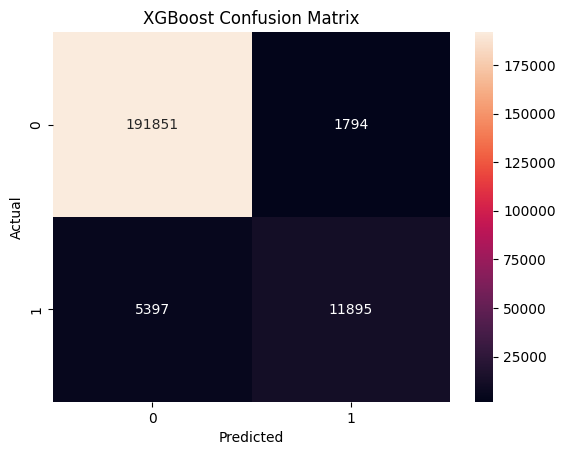

In [83]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [84]:
#for descision tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
joblib.dump(dt, 'dt_model.pkl')

Decision Tree Accuracy: 0.9650748801774938
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    193645
           1       0.86      0.69      0.76     17292

    accuracy                           0.97    210937
   macro avg       0.92      0.84      0.87    210937
weighted avg       0.96      0.97      0.96    210937



['dt_model.pkl']

In [85]:
print(X_train['magType'].unique())
print(X_train['net'].unique())
print(X_train['type'].unique())
print(X_train['status'].unique())

[10 19 14 33 11  1 30 28 32 24 16  7 12 13 22 29  5  9 15 21  6 20 17  2
 35  8 34 23  3  0 27 31 18 25  4]
[27  5 30  1 22 16 10 24 11 29 17 26 18 23 13 12 28  0 20 15  9 14 19  2
  6 25  3  4 21 31  8  7]
[ 7  9 14 15 17 18 10 16 20 13 19  5 11  4  1  6  3  8 12  2]
[2 0 1]


In [86]:
y_pred_dt = dt.predict(X_test)

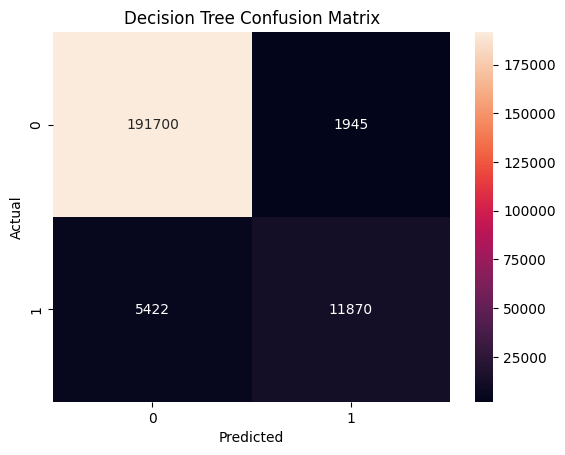

In [87]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [88]:
#for logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42,class_weight='balanced')

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
joblib.dump(lr, 'lr_model.pkl')


Logistic Regression Accuracy: 0.8653010140468481
              precision    recall  f1-score   support

           0       0.97      0.88      0.92    193645
           1       0.35      0.73      0.47     17292

    accuracy                           0.87    210937
   macro avg       0.66      0.80      0.70    210937
weighted avg       0.92      0.87      0.89    210937



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['lr_model.pkl']

In [89]:
print(X_train['magType'].unique())
print(X_train['net'].unique())
print(X_train['type'].unique())
print(X_train['status'].unique())

[10 19 14 33 11  1 30 28 32 24 16  7 12 13 22 29  5  9 15 21  6 20 17  2
 35  8 34 23  3  0 27 31 18 25  4]
[27  5 30  1 22 16 10 24 11 29 17 26 18 23 13 12 28  0 20 15  9 14 19  2
  6 25  3  4 21 31  8  7]
[ 7  9 14 15 17 18 10 16 20 13 19  5 11  4  1  6  3  8 12  2]
[2 0 1]


In [90]:
y_pred_lr = lr.predict(X_test)

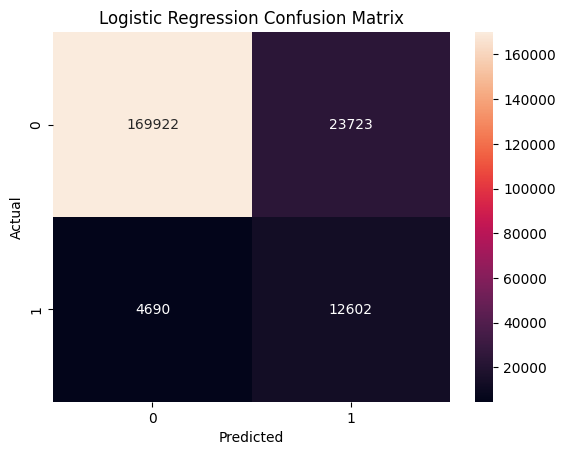

In [91]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [96]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
scaler.fit(X_train)
joblib.dump(scaler, 'scaler.pkl')

print("Scaler created and saved as 'scaler.pkl'")

Scaler created and saved as 'scaler.pkl'


In [97]:
# Load model and scaler
# Make sure to run the cell below this one to create and save the scaler before running this cell.
model = joblib.load('xgb_model.pkl')
scaler = joblib.load('scaler.pkl')

print("\n--- EARTHQUAKE PREDICTION INPUT ---\n")

# Numeric inputs
year = float(input("Year: "))
month = float(input("Month (1-12): "))
hour = float(input("Hour (0-23): "))
latitude = float(input("Latitude (-90 to 90): "))
longitude = float(input("Longitude (-180 to 180): "))
depth = float(input("Depth (km): "))

# Encoded categorical inputs (must match training encoding)
print("\n--- Encoded Feature Inputs (IMPORTANT: use correct values from training) ---")

magType = float(input("magType (encoded): "))
event_type = float(input("type (encoded): "))
net = float(input("net (encoded): "))
status = float(input("status (encoded): "))

# Create DataFrame with correct feature order
feature_names = [
    'year', 'month', 'hour',
    'latitude', 'longitude', 'depth',
    'magType', 'type', 'net', 'status'
]

user_input = pd.DataFrame([[
    year, month, hour,
    latitude, longitude, depth,
    magType, event_type, net, status
]], columns=feature_names)

# Scale input
scaled_input = scaler.transform(user_input)

# Predict probability
probability = model.predict_proba(scaled_input)[0]

# Apply threshold
threshold = 0.7
prediction = 1 if probability[1] > threshold else 0

# Output
print("\n--- RESULT ---\n")

print(f"Low Risk Probability (0): {probability[0]*100:.2f}%")
print(f"High Risk Probability (1): {probability[1]*100:.2f}%")
print(f"Threshold Used: {threshold}")

if prediction == 1:
    print(" EARTHQUAKE ALERT")
else:
    print("LOW RISK")

print(f"Final Prediction: {prediction}")


--- EARTHQUAKE PREDICTION INPUT ---

Year: 2023
Month (1-12): 3
Hour (0-23): 20
Latitude (-90 to 90): 0
Longitude (-180 to 180): 100
Depth (km): 20

--- Encoded Feature Inputs (IMPORTANT: use correct values from training) ---
magType (encoded): 10
type (encoded): 7
net (encoded): 5
status (encoded): 2

--- RESULT ---

Low Risk Probability (0): 24.34%
High Risk Probability (1): 75.66%
Threshold Used: 0.7
 EARTHQUAKE ALERT
Final Prediction: 1


DEEP LEARNING

In [98]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import  Dropout

In [99]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
joblib.dump(model, 'dl_model.pkl')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


['dl_model.pkl']

In [100]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # wait 3  epochs before stopping
    restore_best_weights=True
)

In [102]:
import numpy as np
from sklearn.utils import class_weight

# Compute class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dict properly
class_weights = {
    0: weights[0],
    1: weights[1]
}

print("Class Weights:", class_weights)

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class Weights: {0: np.float64(0.5446502344508479), 1: np.float64(6.099074743385861)}
Epoch 1/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - accuracy: 0.5017 - loss: 0.9247 - val_accuracy: 0.9170 - val_loss: 0.6703
Epoch 2/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.5426 - loss: 0.6937 - val_accuracy: 0.9170 - val_loss: 0.6838
Epoch 3/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 97s 4ms/step - accuracy: 0.5949 - loss: 0.6925 - val_accuracy: 0.0830 - val_loss: 0.7040
Epoch 4/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - accuracy: 0.5260 - loss: 0.6932 - val_accuracy: 0.0830 - val_loss: 0.6933
Epoch 5/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - accuracy: 0.5814 - loss: 0.6923 - val_accuracy: 0.0830 - val_loss: 0.6932
Epoch 6/15
21094/21094 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.5269 - loss: 0.6924 - val_accuracy: 0.9170 - val_loss: 0.6857


In [103]:
y_pred = (model.predict(X_test) > 0.3).astype(int)

6592/6592 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [104]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

6592/6592 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9180 - loss: 0.6702
Accuracy: 0.9180229306221008


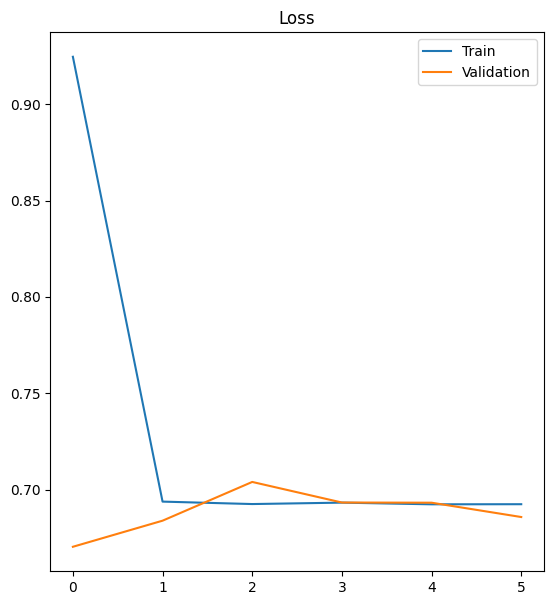

In [105]:
plt.figure(figsize=(14,7))

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

#X-axis → Epochs (for training cycles)
#Y-axis → Accuracy (for correct predictions)

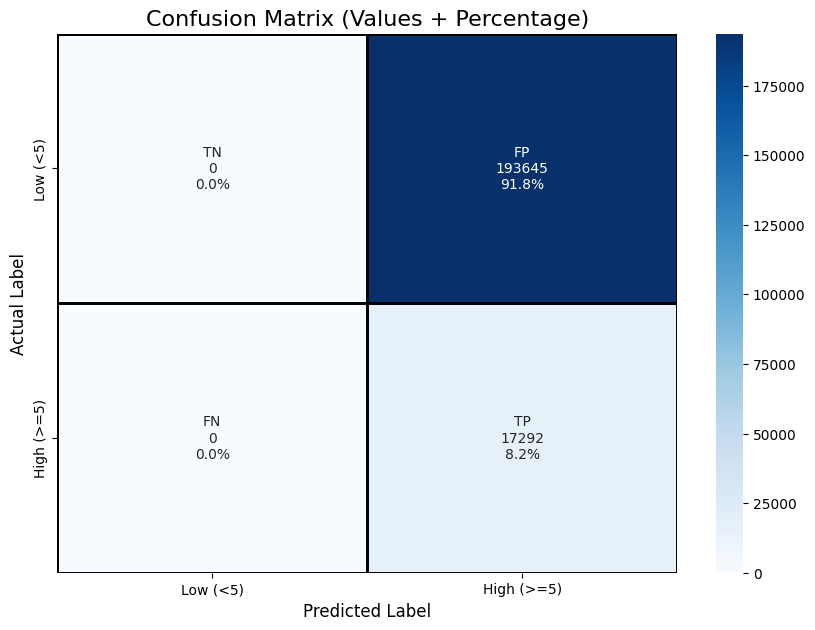

In [106]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Values
tn, fp, fn, tp = cm.ravel()

# Calculate percentages
cm_percent = cm / cm.sum()

# Labels with value + %
labels = np.array([
    [f"TN\n{tn}\n{cm_percent[0,0]*100:.1f}%",
     f"FP\n{fp}\n{cm_percent[0,1]*100:.1f}%"],

    [f"FN\n{fn}\n{cm_percent[1,0]*100:.1f}%",
     f"TP\n{tp}\n{cm_percent[1,1]*100:.1f}%"]
])

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(cm,
            annot=labels,
            fmt='',
            cmap='Blues',
            linewidths=1,
            linecolor='black',
            xticklabels=['Low (<5)', 'High (>=5)'],
            yticklabels=['Low (<5)', 'High (>=5)'])

plt.title("Confusion Matrix (Values + Percentage)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.show()

Receiver Operating Characteristic Curve(for model classification)

### Detailed Classification Reports

6592/6592 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


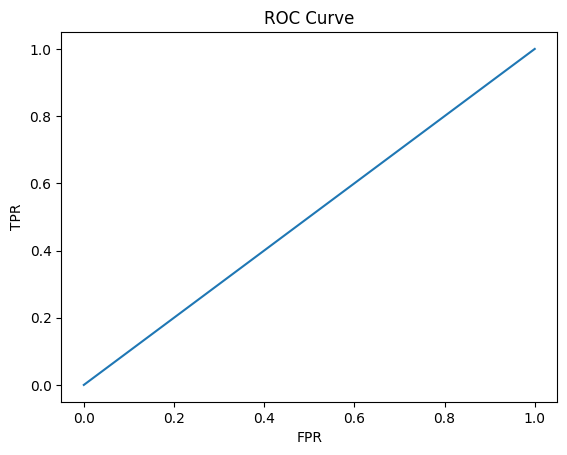

In [107]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)                 #AUC (Area Under Curve)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

#X-axis → False Positive Rate (FPR)
#Y-axis → True Positive Rate (TPR)

In [108]:
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_pred))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_pred))

# For Deep Learning, generate predictions first to get the report
y_pred_dl_binary = (model.predict(X_test) > 0.5).astype(int)
print("\n--- Deep Learning Classification Report ---")
print(classification_report(y_test, y_pred_dl_binary))


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    193645
           1       0.87      0.69      0.77     17292

    accuracy                           0.97    210937
   macro avg       0.92      0.84      0.87    210937
weighted avg       0.96      0.97      0.96    210937


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    193645
           1       0.86      0.69      0.76     17292

    accuracy                           0.97    210937
   macro avg       0.92      0.84      0.87    210937
weighted avg       0.96      0.97      0.96    210937


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.88      0.92    193645
           1       0.35      0.73      0.47     17292

    accuracy                           0.87    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
